Pairwise Target Consistency Analysis
Folder: ../outputs
----------------------------------------
Found 16 variations


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


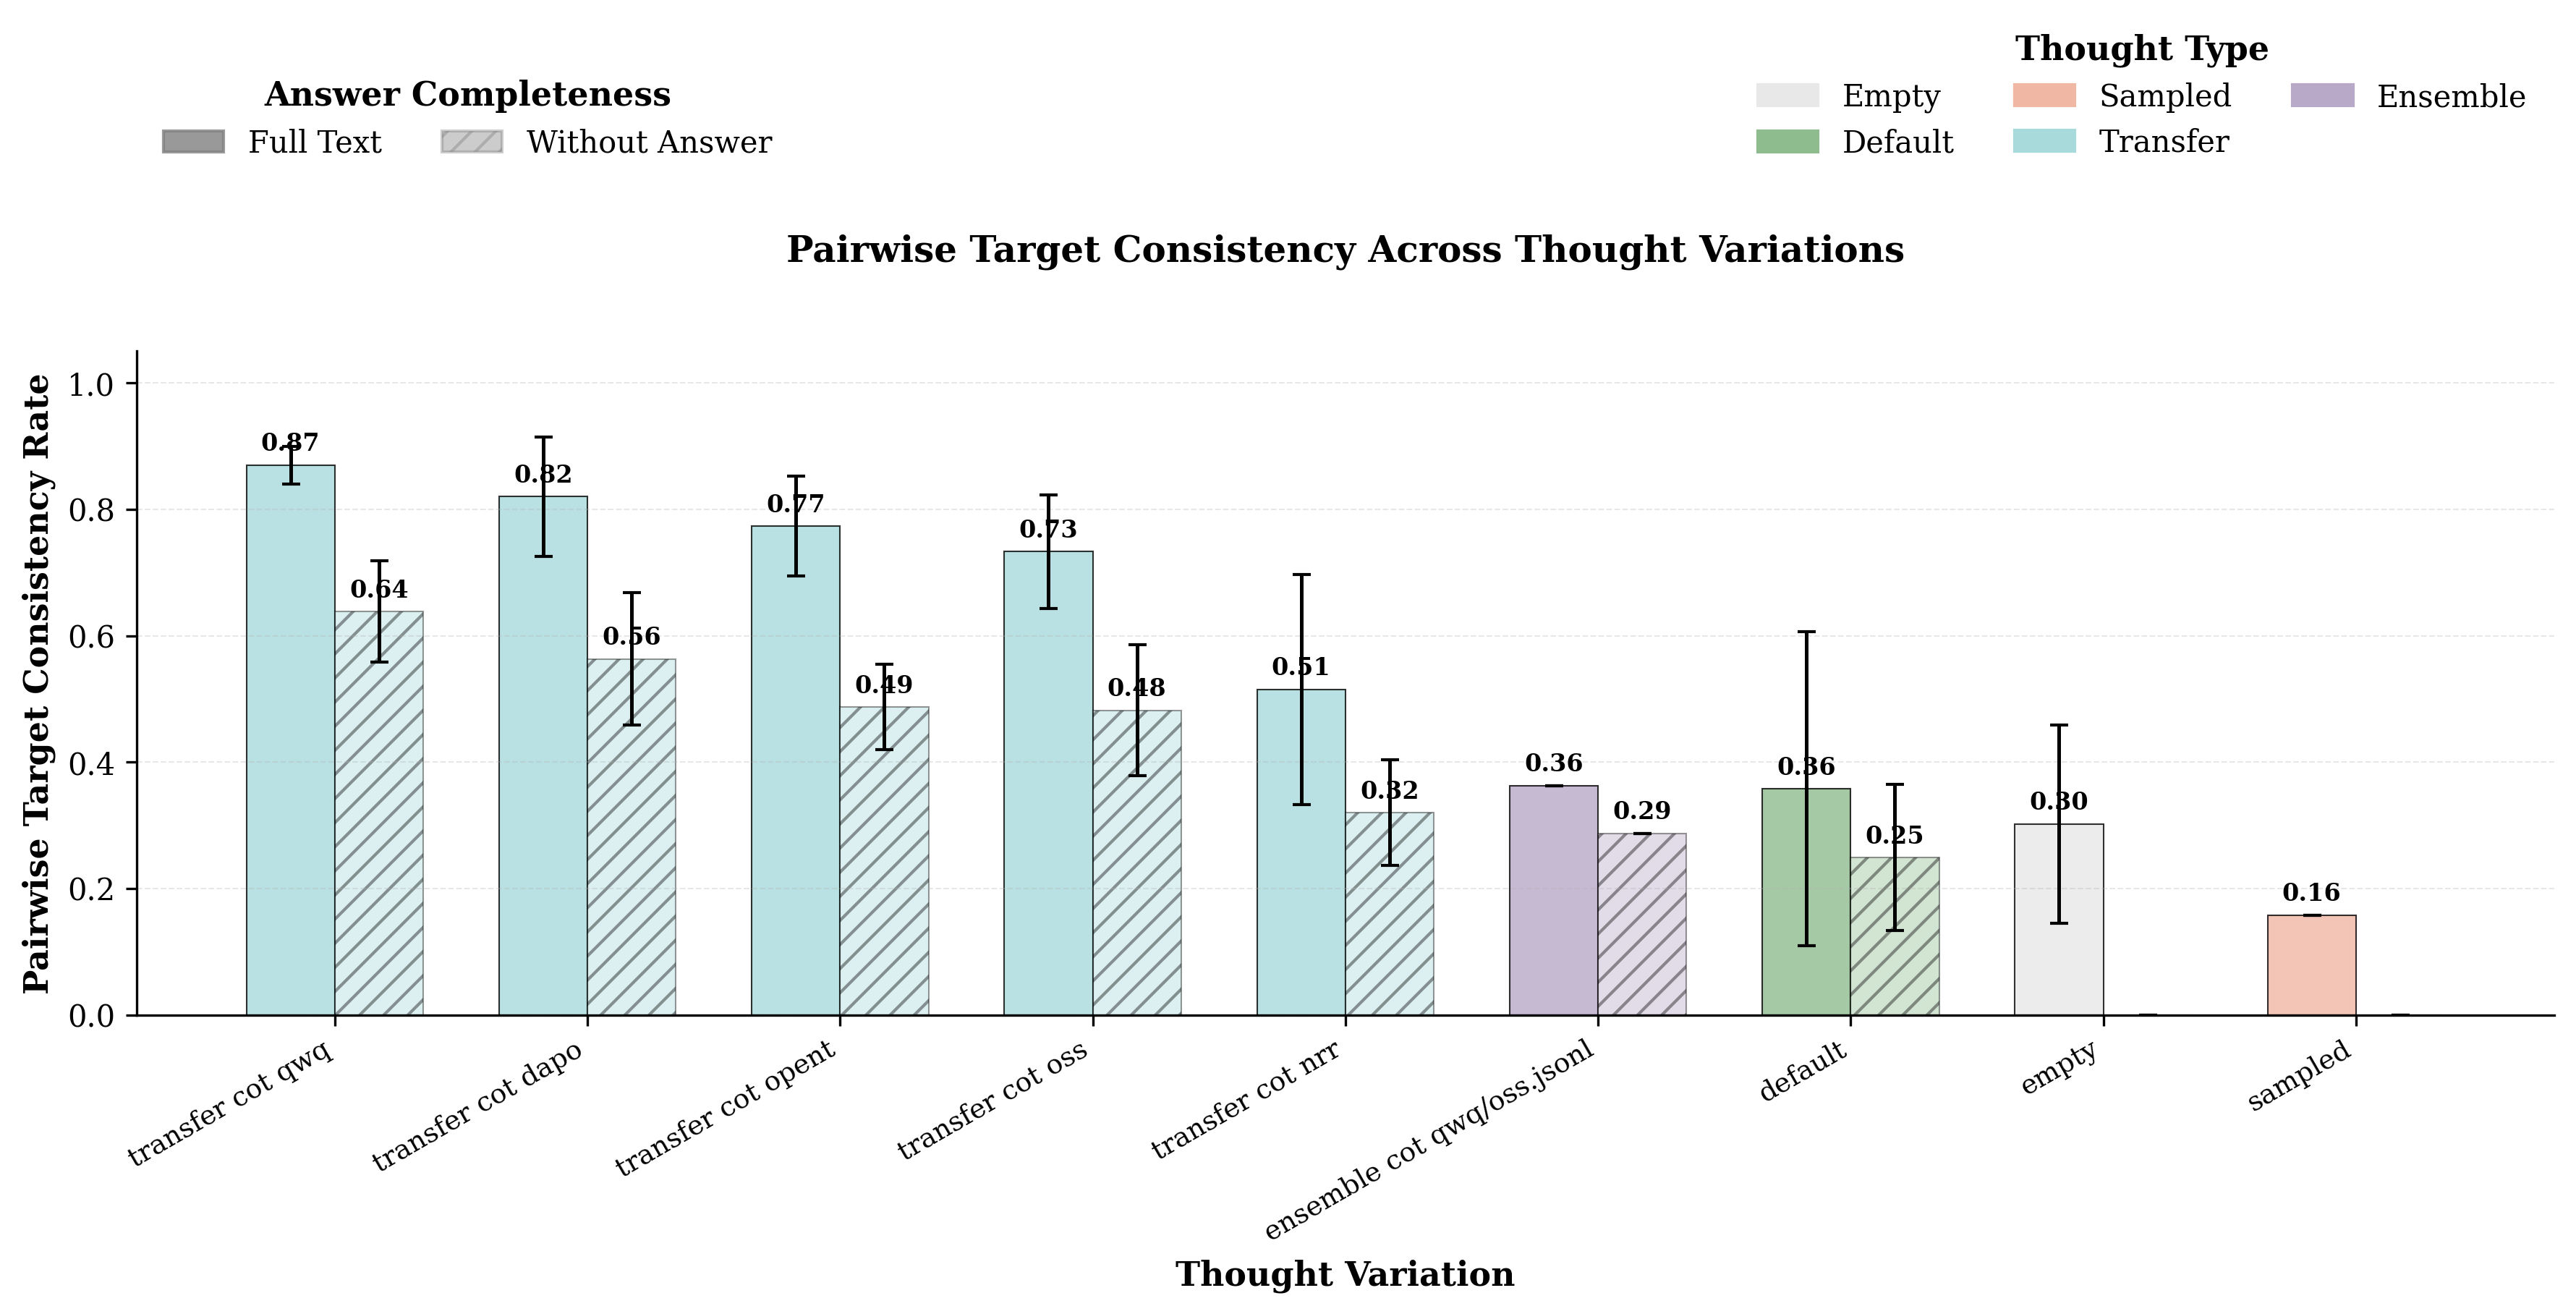


PAIRWISE TARGET CONSISTENCY ANALYSIS
 1. transfer cot qwq
     Full Text:   0.870 ± 0.030 (n=10)
     Without Ans: 0.638 ± 0.080 (n=10)
     Difference:  +0.232

 2. transfer cot dapo
     Full Text:   0.820 ± 0.094 (n=10)
     Without Ans: 0.563 ± 0.105 (n=10)
     Difference:  +0.257

 3. transfer cot opent
     Full Text:   0.773 ± 0.079 (n=10)
     Without Ans: 0.487 ± 0.068 (n=10)
     Difference:  +0.286

 4. transfer cot oss
     Full Text:   0.733 ± 0.090 (n=10)
     Without Ans: 0.482 ± 0.104 (n=10)
     Difference:  +0.251

 5. transfer cot nrr
     Full Text:   0.515 ± 0.182 (n=10)
     Without Ans: 0.320 ± 0.084 (n=10)
     Difference:  +0.195

 6. ensemble cot qwq/oss.jsonl
     Full Text:   0.363 ± 0.000 (n=1)
     Without Ans: 0.287 ± 0.000 (n=1)
     Difference:  +0.075

 7. default
     Full Text:   0.357 ± 0.249 (n=45)
     Without Ans: 0.249 ± 0.115 (n=10)
     Difference:  +0.108

 8. empty
     Full Text:   0.302 ± 0.157 (n=10)

 9. sampled
     Full Text:   0.158

In [29]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# LaTeX paper configuration
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

MODEL_NAMES = {
    'openai_gpt-oss-20b': 'oss',
    'BytedTsinghua-SIA_DAPO-Qwen-32B': 'dapo', 
    'Qwen_QwQ-32B': 'qwq',
    'open-thoughts_OpenThinker-7B': 'opent',
    'nvidia_Nemotron-Research-Reasoning-Qwen-1.5B': 'nrr'
}

COLORS = {
    'empty': '#E8E8E8', 'default': '#8FBC8F', 'sampled': '#F0B7A4',
    'transfer': '#A8DADC', 'ensemble': '#B8A9C9'
}

def parse_jsonl(filepath):
    try:
        with open(filepath, 'r') as f:
            return [json.loads(line) for line in f if line.strip()]
    except:
        return []

def get_variation(filename):
    without_ans = 'without_answer' in filename
    
    if '_zero_shot_empty.jsonl' in filename:
        return ['empty']
    
    if ('_zero_shot_original.jsonl' in filename or '_zero_shot_original_low.jsonl' in filename):
        return ['default without ans' if without_ans else 'default full text']
    
    if '_with_sampling.jsonl' in filename:
        return ['sampled without ans' if without_ans else 'sampled full text']
    
    match = re.match(r'(.+)_thoughts_to_(.+)_zero_shot', filename)
    if match:
        source, target = match.groups()
        suffix = 'without ans' if without_ans else 'full text'
        
        if source == target:
            short_source = MODEL_NAMES.get(source, source).lower()
            return [f'default {suffix}', f'transfer cot {short_source} {suffix}']
        else:
            short_source = MODEL_NAMES.get(source, source).lower()
            return [f'transfer cot {short_source} {suffix}']
    
    if '_gen_' in filename and '_eval_' in filename:
        gen = re.search(r'_gen_([^_]+)', filename)
        eval_match = re.search(r'_eval_([^_]+)', filename)
        if gen and eval_match:
            gen_short = MODEL_NAMES.get(gen.group(1), gen.group(1)).lower()
            eval_short = MODEL_NAMES.get(eval_match.group(1), eval_match.group(1)).lower()
            suffix = 'without ans' if without_ans else 'full text'
            return [f'ensemble cot {gen_short}/{eval_short} {suffix}']
    
    return []

def get_target_model(filename):
    if '_thoughts_to_' in filename:
        match = re.match(r'.+_thoughts_to_(.+)_zero_shot', filename)
        return match.group(1) if match else None
    
    for model in MODEL_NAMES:
        if model in filename:
            return model
    return None

def check_consistency(dp1, dp2, is_thoughts_to):
    fields = ("Target Answer", "Target Result") if is_thoughts_to else ("LLM Answer", "Result")
    
    ans1, res1 = dp1.get(fields[0], ""), dp1.get(fields[1], "")
    ans2, res2 = dp2.get(fields[0], ""), dp2.get(fields[1], "")
    
    invalid = ["not defined", "N/A", "does not match", "are not permitted"]
    if any(p in ans1 or p in ans2 for p in invalid):
        return None
    
    return 1 if ans1 == ans2 or (res1 == "Correct" and res2 == "Correct") else 0

def calculate_pairwise_consistency(folder_path):
    if not os.path.exists(folder_path):
        return {}
    
    variation_files = defaultdict(list)
    
    for filename in os.listdir(folder_path):
        if not filename.endswith('.jsonl'):
            continue
            
        variations = get_variation(filename)
        target = get_target_model(filename)
        
        if variations and target:
            for variation in variations:
                variation_files[variation].append((target, filename))
    
    results = {}
    
    for variation, files in variation_files.items():
        if len(files) < 2:
            continue
            
        rates = []
        is_thoughts_to = '_thoughts_to_' in files[0][1]
        
        for i in range(len(files)):
            for j in range(i + 1, len(files)):
                data1 = parse_jsonl(os.path.join(folder_path, files[i][1]))
                data2 = parse_jsonl(os.path.join(folder_path, files[j][1]))
                
                if not data1 or not data2:
                    continue
                
                consistent = total = 0
                for dp1, dp2 in zip(data1, data2):
                    result = check_consistency(dp1, dp2, is_thoughts_to)
                    if result is not None:
                        total += 1
                        consistent += result
                
                if total > 0:
                    rates.append(consistent / total)
        
        if rates:
            results[variation] = {'mean': np.mean(rates), 'std': np.std(rates), 'count': len(rates)}
    
    return results

def plot_results(results):
    if not results:
        return []
    
    # Group by base thought type
    grouped = {}
    for name, data in results.items():
        if name.endswith(' full text'):
            base = name.replace(' full text', '')
            if base not in grouped:
                grouped[base] = {}
            grouped[base]['full'] = data
        elif name.endswith(' without ans'):
            base = name.replace(' without ans', '')
            if base not in grouped:
                grouped[base] = {}
            grouped[base]['without'] = data
        else:
            grouped[name] = {'full': data}
    
    # Sort by performance
    def sort_key(item):
        name, variants = item
        if 'full' in variants and 'without' in variants:
            return (variants['full']['mean'] + variants['without']['mean']) / 2
        return variants.get('full', variants.get('without'))['mean']
    
    sorted_groups = sorted(grouped.items(), key=sort_key, reverse=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    names = [name for name, _ in sorted_groups]
    x = np.arange(len(names))
    width = 0.35
    
    # Prepare data and colors
    full_means, full_stds, without_means, without_stds, colors = [], [], [], [], []
    
    for name, variants in sorted_groups:
        full_means.append(variants['full']['mean'] if 'full' in variants else 0)
        full_stds.append(variants['full']['std'] if 'full' in variants else 0)
        without_means.append(variants['without']['mean'] if 'without' in variants else 0)
        without_stds.append(variants['without']['std'] if 'without' in variants else 0)
        
        for key, color in COLORS.items():
            if key in name:
                colors.append(color)
                break
        else:
            colors.append('#E2E2DF')
    
    # Create bars
    bars1 = ax.bar(x - width/2, full_means, width, yerr=full_stds, 
                   color=colors, alpha=0.8, capsize=3, label='Full Text', 
                   edgecolor='black', linewidth=0.5)
    
    bars2 = ax.bar(x + width/2, without_means, width, yerr=without_stds,
                   color=colors, alpha=0.4, capsize=3, label='Without Answer',
                   edgecolor='black', linewidth=0.5, hatch='///')
    
    # Styling
    ax.set_xlabel('Thought Variation', fontweight='bold')
    ax.set_ylabel('Pairwise Target Consistency Rate', fontweight='bold')
    ax.set_title('Pairwise Target Consistency Across Thought Variations', 
                 fontweight='bold', pad=30)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Value labels
    for bars, means in [(bars1, full_means), (bars2, without_means)]:
        for bar, mean in zip(bars, means):
            if mean > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                        f'{mean:.2f}', ha='center', va='bottom', 
                        fontsize=8, fontweight='bold')
    
    # Legends
    from matplotlib.patches import Patch
    
    answer_handles = [
        Patch(color='gray', alpha=0.8, label='Full Text'),
        Patch(color='gray', alpha=0.4, label='Without Answer', hatch='///')
    ]
    
    thought_handles = [Patch(color=color, label=label.title()) 
                      for label, color in COLORS.items()]
    
    legend1 = ax.legend(handles=answer_handles, loc='lower left', 
                       bbox_to_anchor=(0, 1.25), ncol=2, frameon=False,
                       title='Answer Completeness')
    legend1.get_title().set_fontweight('bold')
    
    legend2 = ax.legend(handles=thought_handles, loc='lower right',
                       bbox_to_anchor=(1, 1.25), ncol=3, frameon=False,
                       title='Thought Type')
    legend2.get_title().set_fontweight('bold')
    
    ax.add_artist(legend1)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.75)
    
    plt.savefig('pairwise_consistency.pdf', bbox_inches='tight', facecolor='white')
    plt.savefig('pairwise_consistency.eps', bbox_inches='tight', facecolor='white')
    plt.show()
    
    return sorted_groups

def print_summary(sorted_groups):
    print("\nPAIRWISE TARGET CONSISTENCY ANALYSIS")
    print("=" * 50)
    
    for i, (name, variants) in enumerate(sorted_groups):
        print(f"{i+1:2d}. {name}")
        
        if 'full' in variants:
            data = variants['full']
            print(f"     Full Text:   {data['mean']:.3f} ± {data['std']:.3f} (n={data['count']})")
        
        if 'without' in variants:
            data = variants['without']
            print(f"     Without Ans: {data['mean']:.3f} ± {data['std']:.3f} (n={data['count']})")
        
        if 'full' in variants and 'without' in variants:
            diff = variants['full']['mean'] - variants['without']['mean']
            print(f"     Difference:  {diff:+.3f}")
        print()

def main(folder_path):
    print("Pairwise Target Consistency Analysis")
    print(f"Folder: {folder_path}")
    print("-" * 40)
    
    results = calculate_pairwise_consistency(folder_path)
    
    if not results:
        print("No valid comparisons found.")
        return
    
    print(f"Found {len(results)} variations")
    
    sorted_groups = plot_results(results)
    print_summary(sorted_groups)
    print("Analysis complete.")

if __name__ == "__main__":
    main("../outputs")